# تحميل (استيراد) المكتبات الأساسية
# Importing

In [7]:
## Re-import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt


# تحميل البيانات Data downloading

In [8]:
## Reload the dataset
# https://www.sidc.be/observations/space-based-timelines/tsi
tsi_file = "ROB_TSI_composite_latest.txt"
df_tsi = pd.read_csv(
    tsi_file,
    delim_whitespace=True,
    comment="#",
    header=None,
    usecols=[0, 1],
    names=["Year", "TSI"],
    encoding="ISO-8859-1"
)

## Convert fractional year to datetime
df_tsi["Date"] = pd.to_datetime(df_tsi["Year"], format='%Y') + pd.to_timedelta((df_tsi["Year"] % 1) * 365.25, unit='D')

## Filter from 1975 onward and apply smoothing
df_tsi_filtered = df_tsi[df_tsi["Date"] >= "1975-01-01"].copy()
df_tsi_filtered["Smoothed"] = df_tsi_filtered["TSI"].rolling(window=365, center=True).mean()

## Define solar cycle years and numbers
cycle_years = [1976, 1986, 1996, 2008, 2019]
cycle_numbers = [21, 22, 23, 24, 25]

/var/folders/jh/6nq_ym693fn165j5sx8tmqy00000gn/T/ipykernel_85647/4119004383.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_tsi = pd.read_csv(


# العرض Visualization

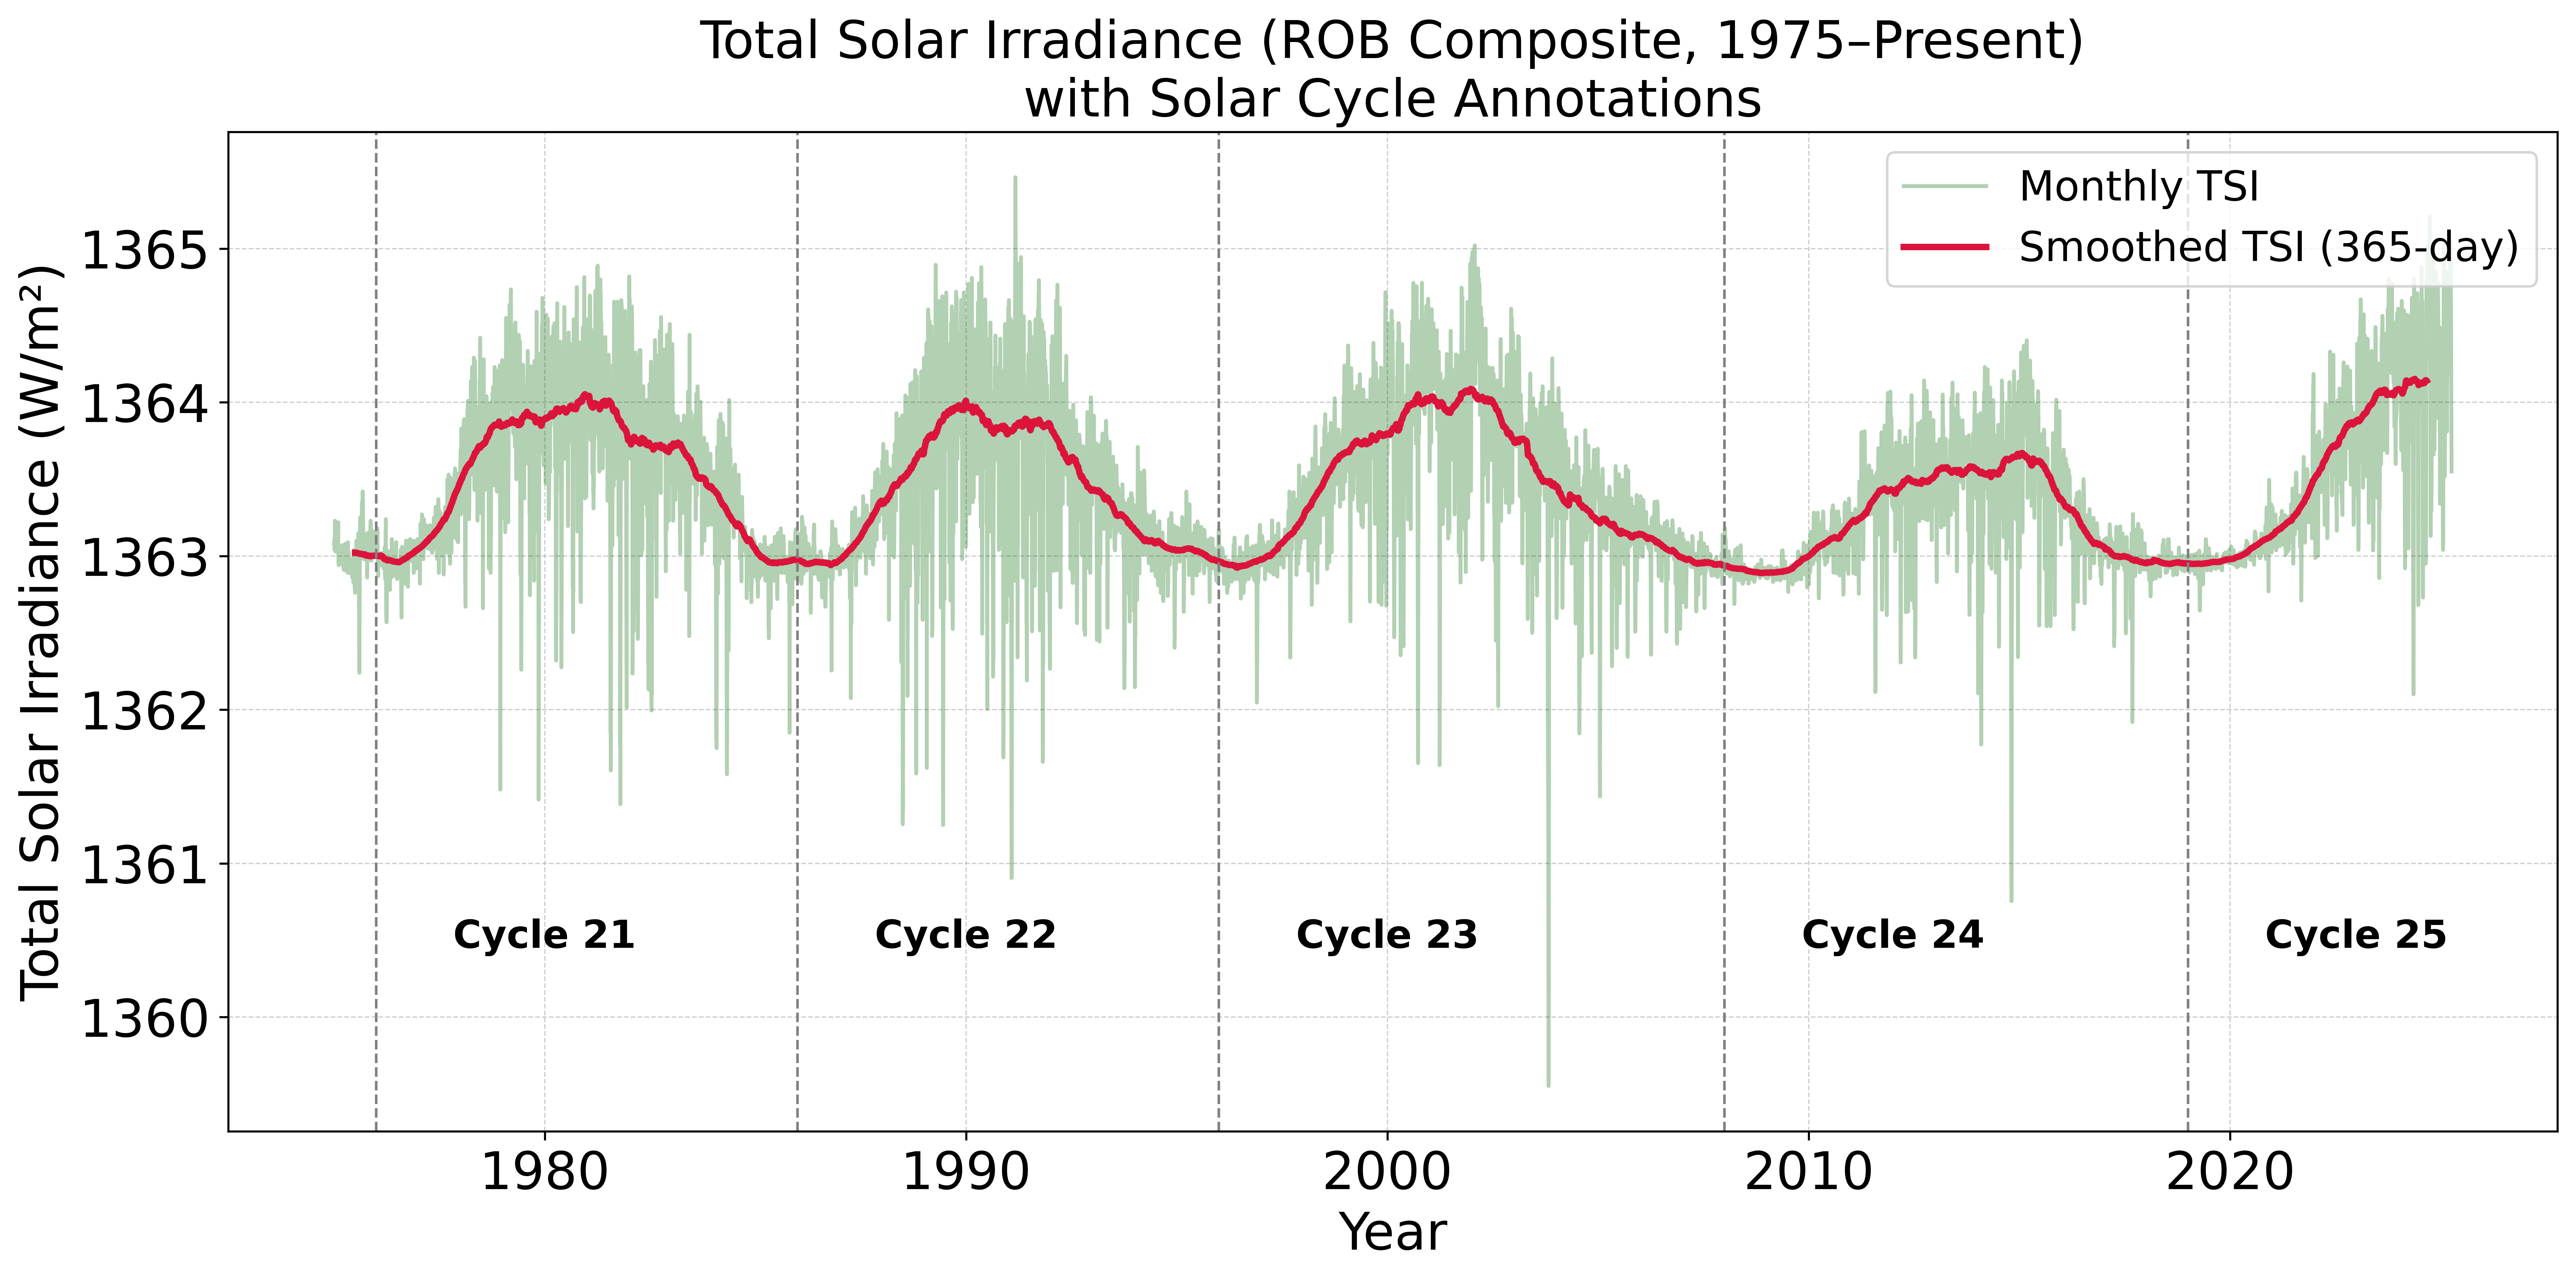

In [9]:
## Plot enhanced TSI with annotations
plt.figure(figsize=(14, 7), dpi=600)
plt.plot(df_tsi_filtered["Date"], df_tsi_filtered["TSI"], color='darkgreen', alpha=0.3, label='Monthly TSI')
plt.plot(df_tsi_filtered["Date"], df_tsi_filtered["Smoothed"], color='crimson', linewidth=2.5, label='Smoothed TSI (365-day)')

## Annotate solar cycles
for year, number in zip(cycle_years, cycle_numbers):
    plt.axvline(pd.Timestamp(f"{year}-01-01"), color='gray', linestyle='--', linewidth=1)
    plt.text(pd.Timestamp(f"{year+4}-01-01"), 1360.45, f"Cycle {number}", fontsize=15, color='black', ha='center', fontweight='bold')

plt.title("Total Solar Irradiance (ROB Composite, 1975–Present)\nwith Solar Cycle Annotations", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Solar Irradiance (W/m²)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()


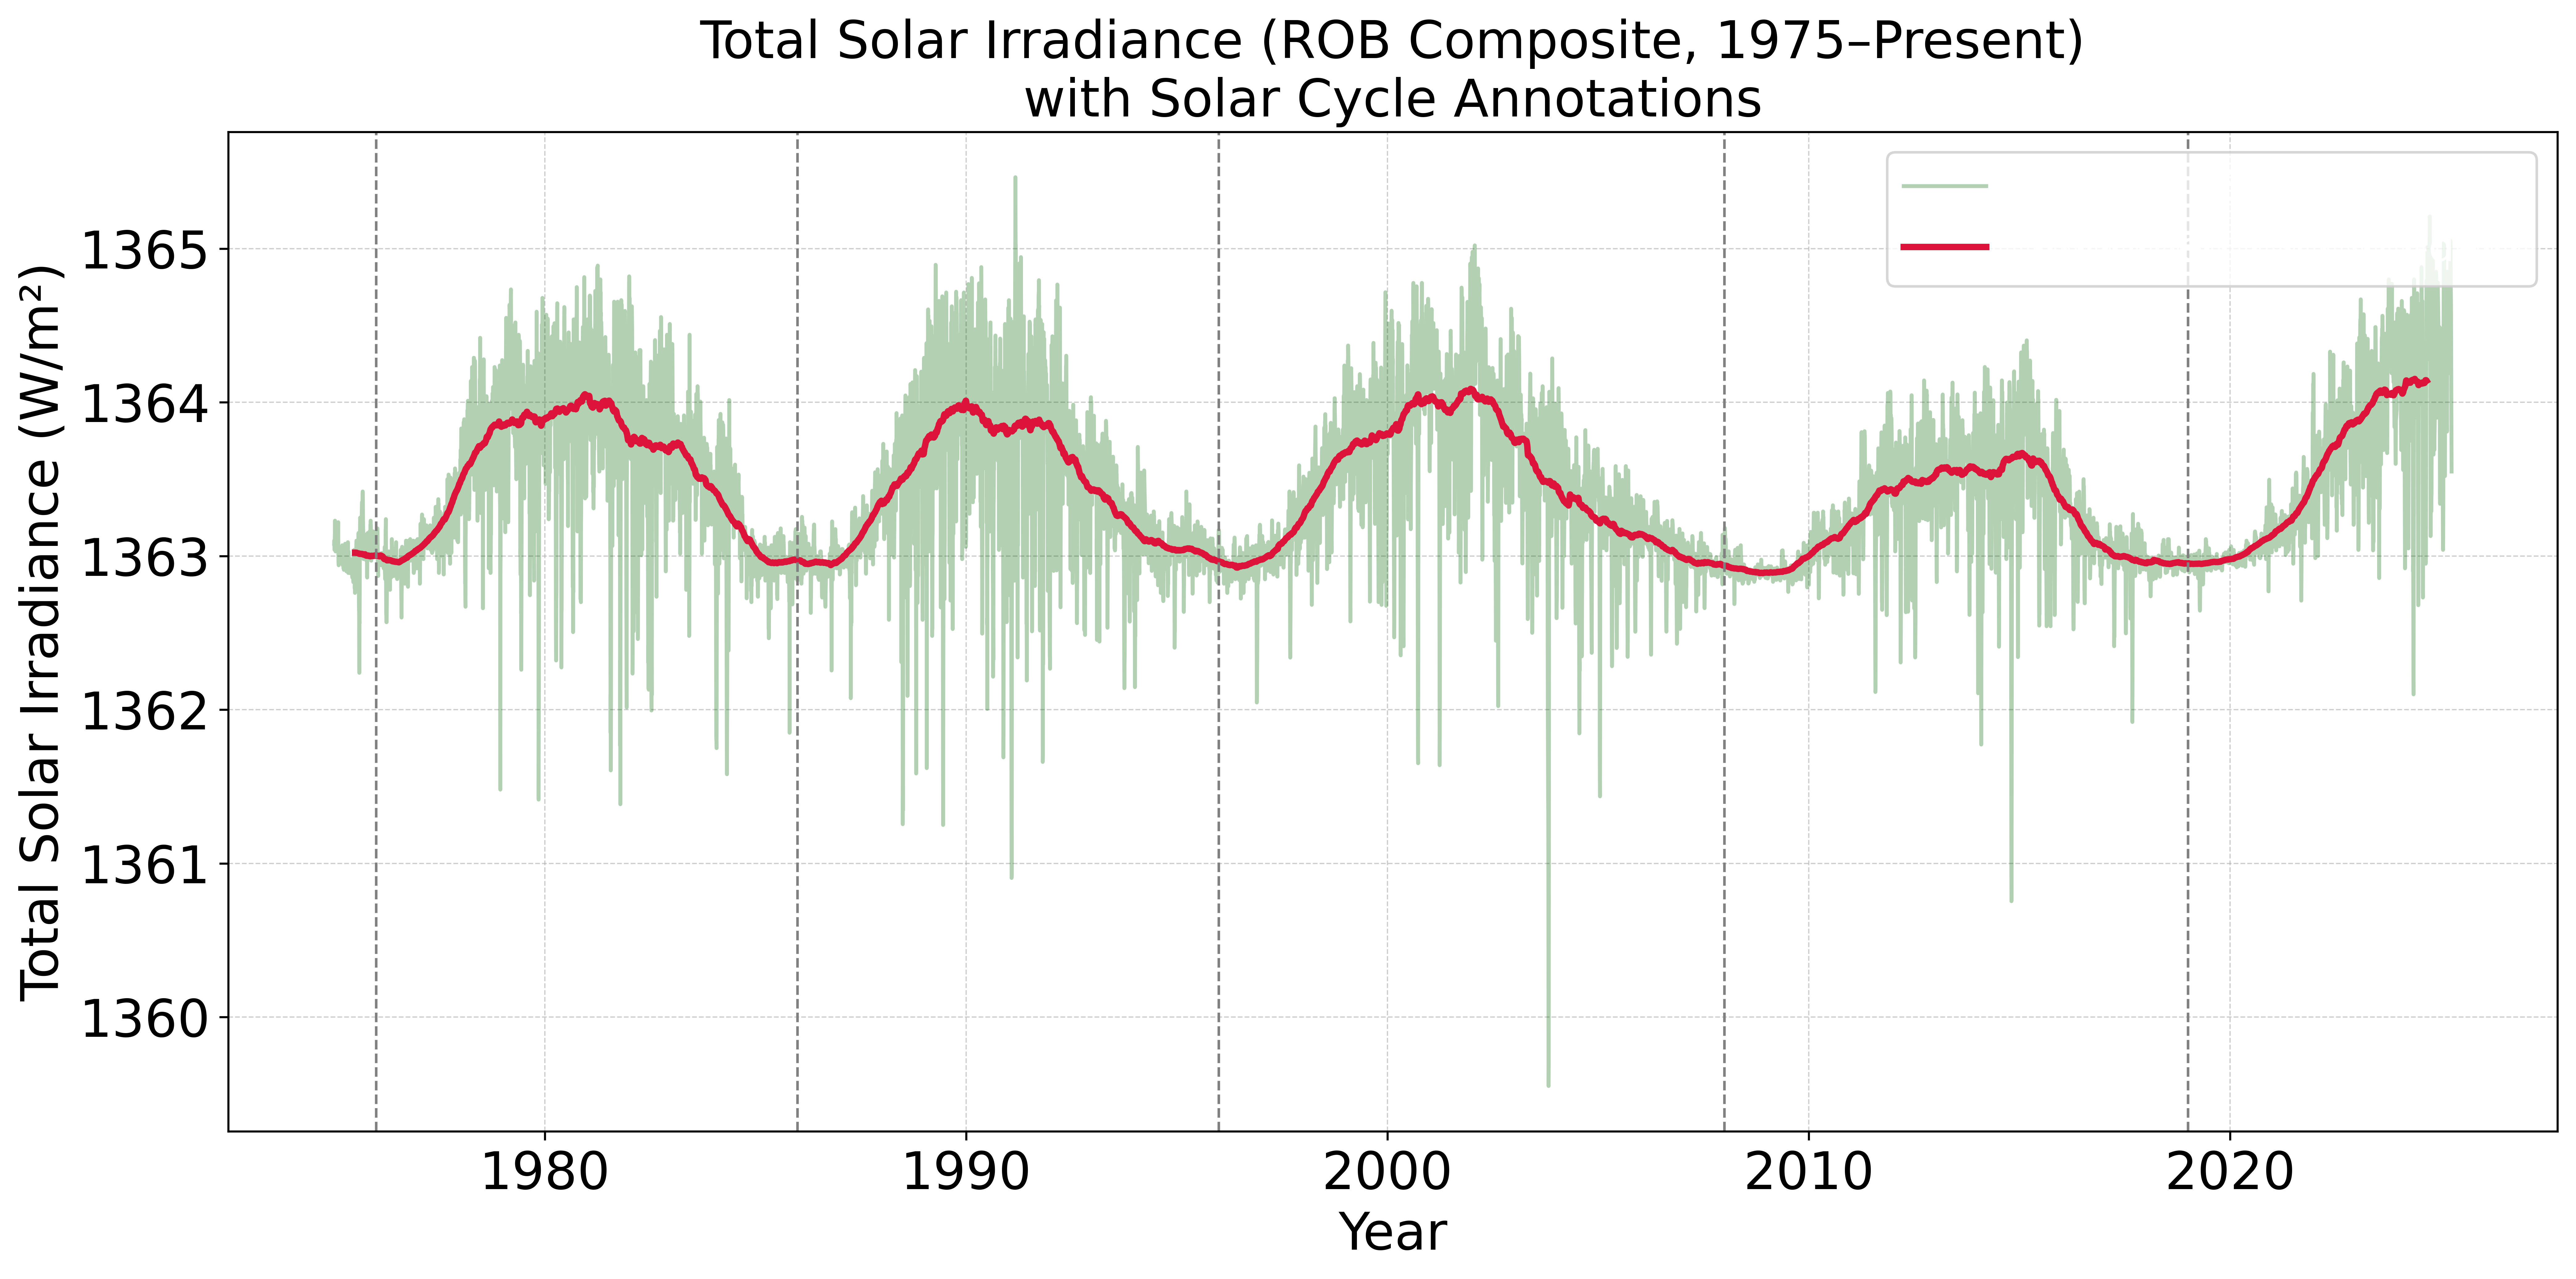

In [10]:
## Plot enhanced TSI with annotations
plt.figure(figsize=(14, 7), dpi=600)
plt.plot(df_tsi_filtered["Date"], df_tsi_filtered["TSI"], color='darkgreen', alpha=0.3, label='Monthly TSI')
plt.plot(df_tsi_filtered["Date"], df_tsi_filtered["Smoothed"], color='crimson', linewidth=2.5, label='Smoothed TSI (365-day)')

## Annotate solar cycles
for year, number in zip(cycle_years, cycle_numbers):
    plt.axvline(pd.Timestamp(f"{year}-01-01"), color='gray', linestyle='--', linewidth=1)
    #plt.text(pd.Timestamp(f"{year+4}-01-01"), 1360.45, f"Cycle {number}", fontsize=10, color='black', ha='center', fontweight='bold')

plt.title("Total Solar Irradiance (ROB Composite, 1975–Present)\nwith Solar Cycle Annotations", fontsize=20)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total Solar Irradiance (W/m²)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
legend = plt.legend(loc='upper right', fontsize=16)
for text in legend.get_texts():
    text.set_color("white") 
    
plt.show()


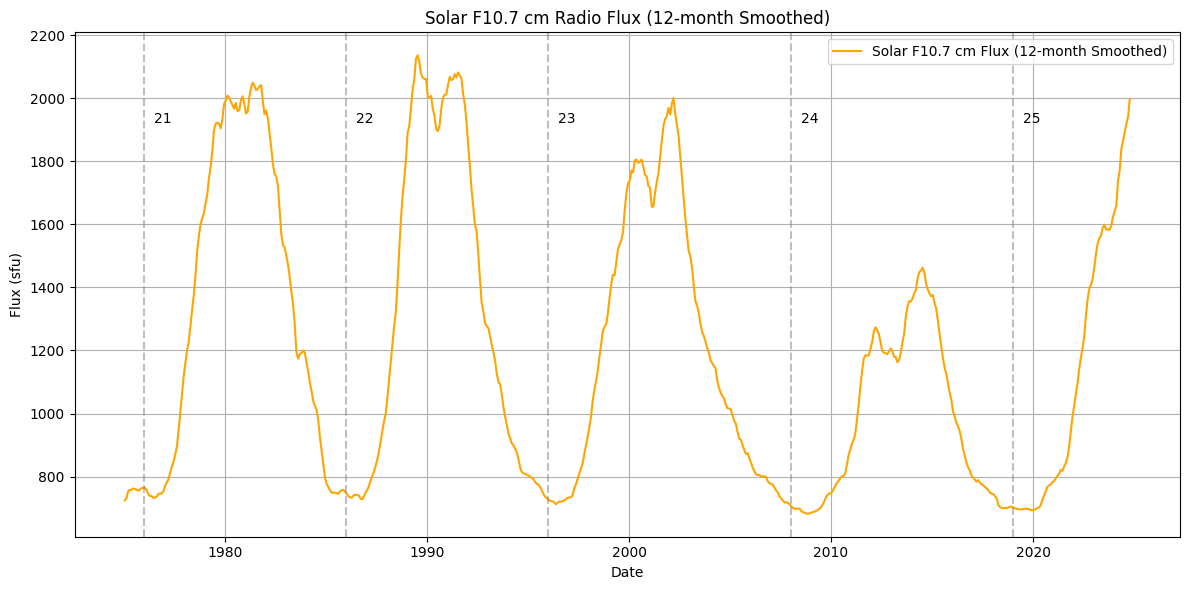

In [11]:


# === Load Solar F10.7 Data from Uploaded File ===
file_path = "sole flux.txt"

# Parse the text file: first column is year, followed by 12 monthly values
data = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 13 and parts[0].isdigit():
            year = int(parts[0])
            for month in range(1, 13):
                try:
                    flux = float(parts[month])
                except ValueError:
                    continue
                if flux > 0:  # filter out -999 placeholders
                    data.append([year, month, flux])

# Create DataFrame
df = pd.DataFrame(data, columns=['Y', 'M', 'flux'])
df['date'] = pd.to_datetime(dict(year=df['Y'], month=df['M'], day=15))

# Filter from 1975 onward and sort
df_filtered = df[df['date'] >= '1975-01-01'].copy()
df_filtered.sort_values('date', inplace=True)

# Apply smoothing (12-month rolling)
df_filtered['Smoothed'] = df_filtered['flux'].rolling(window=12, center=True, min_periods=1).mean()

# Solar cycle markers
cycle_years = [1976, 1986, 1996, 2008, 2019]
cycle_numbers = [21, 22, 23, 24, 25]

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['Smoothed'], label='Solar F10.7 cm Flux (12-month Smoothed)', color='orange')
plt.title('Solar F10.7 cm Radio Flux (12-month Smoothed)')
plt.xlabel('Date')
plt.ylabel('Flux (sfu)')
plt.grid(True)
for y, n in zip(cycle_years, cycle_numbers):
    plt.axvline(pd.Timestamp(f"{y}-01-01"), color='gray', linestyle='--', alpha=0.5)
    plt.text(pd.Timestamp(f"{y}-07-01"), df_filtered['Smoothed'].max()*0.9, str(n), rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


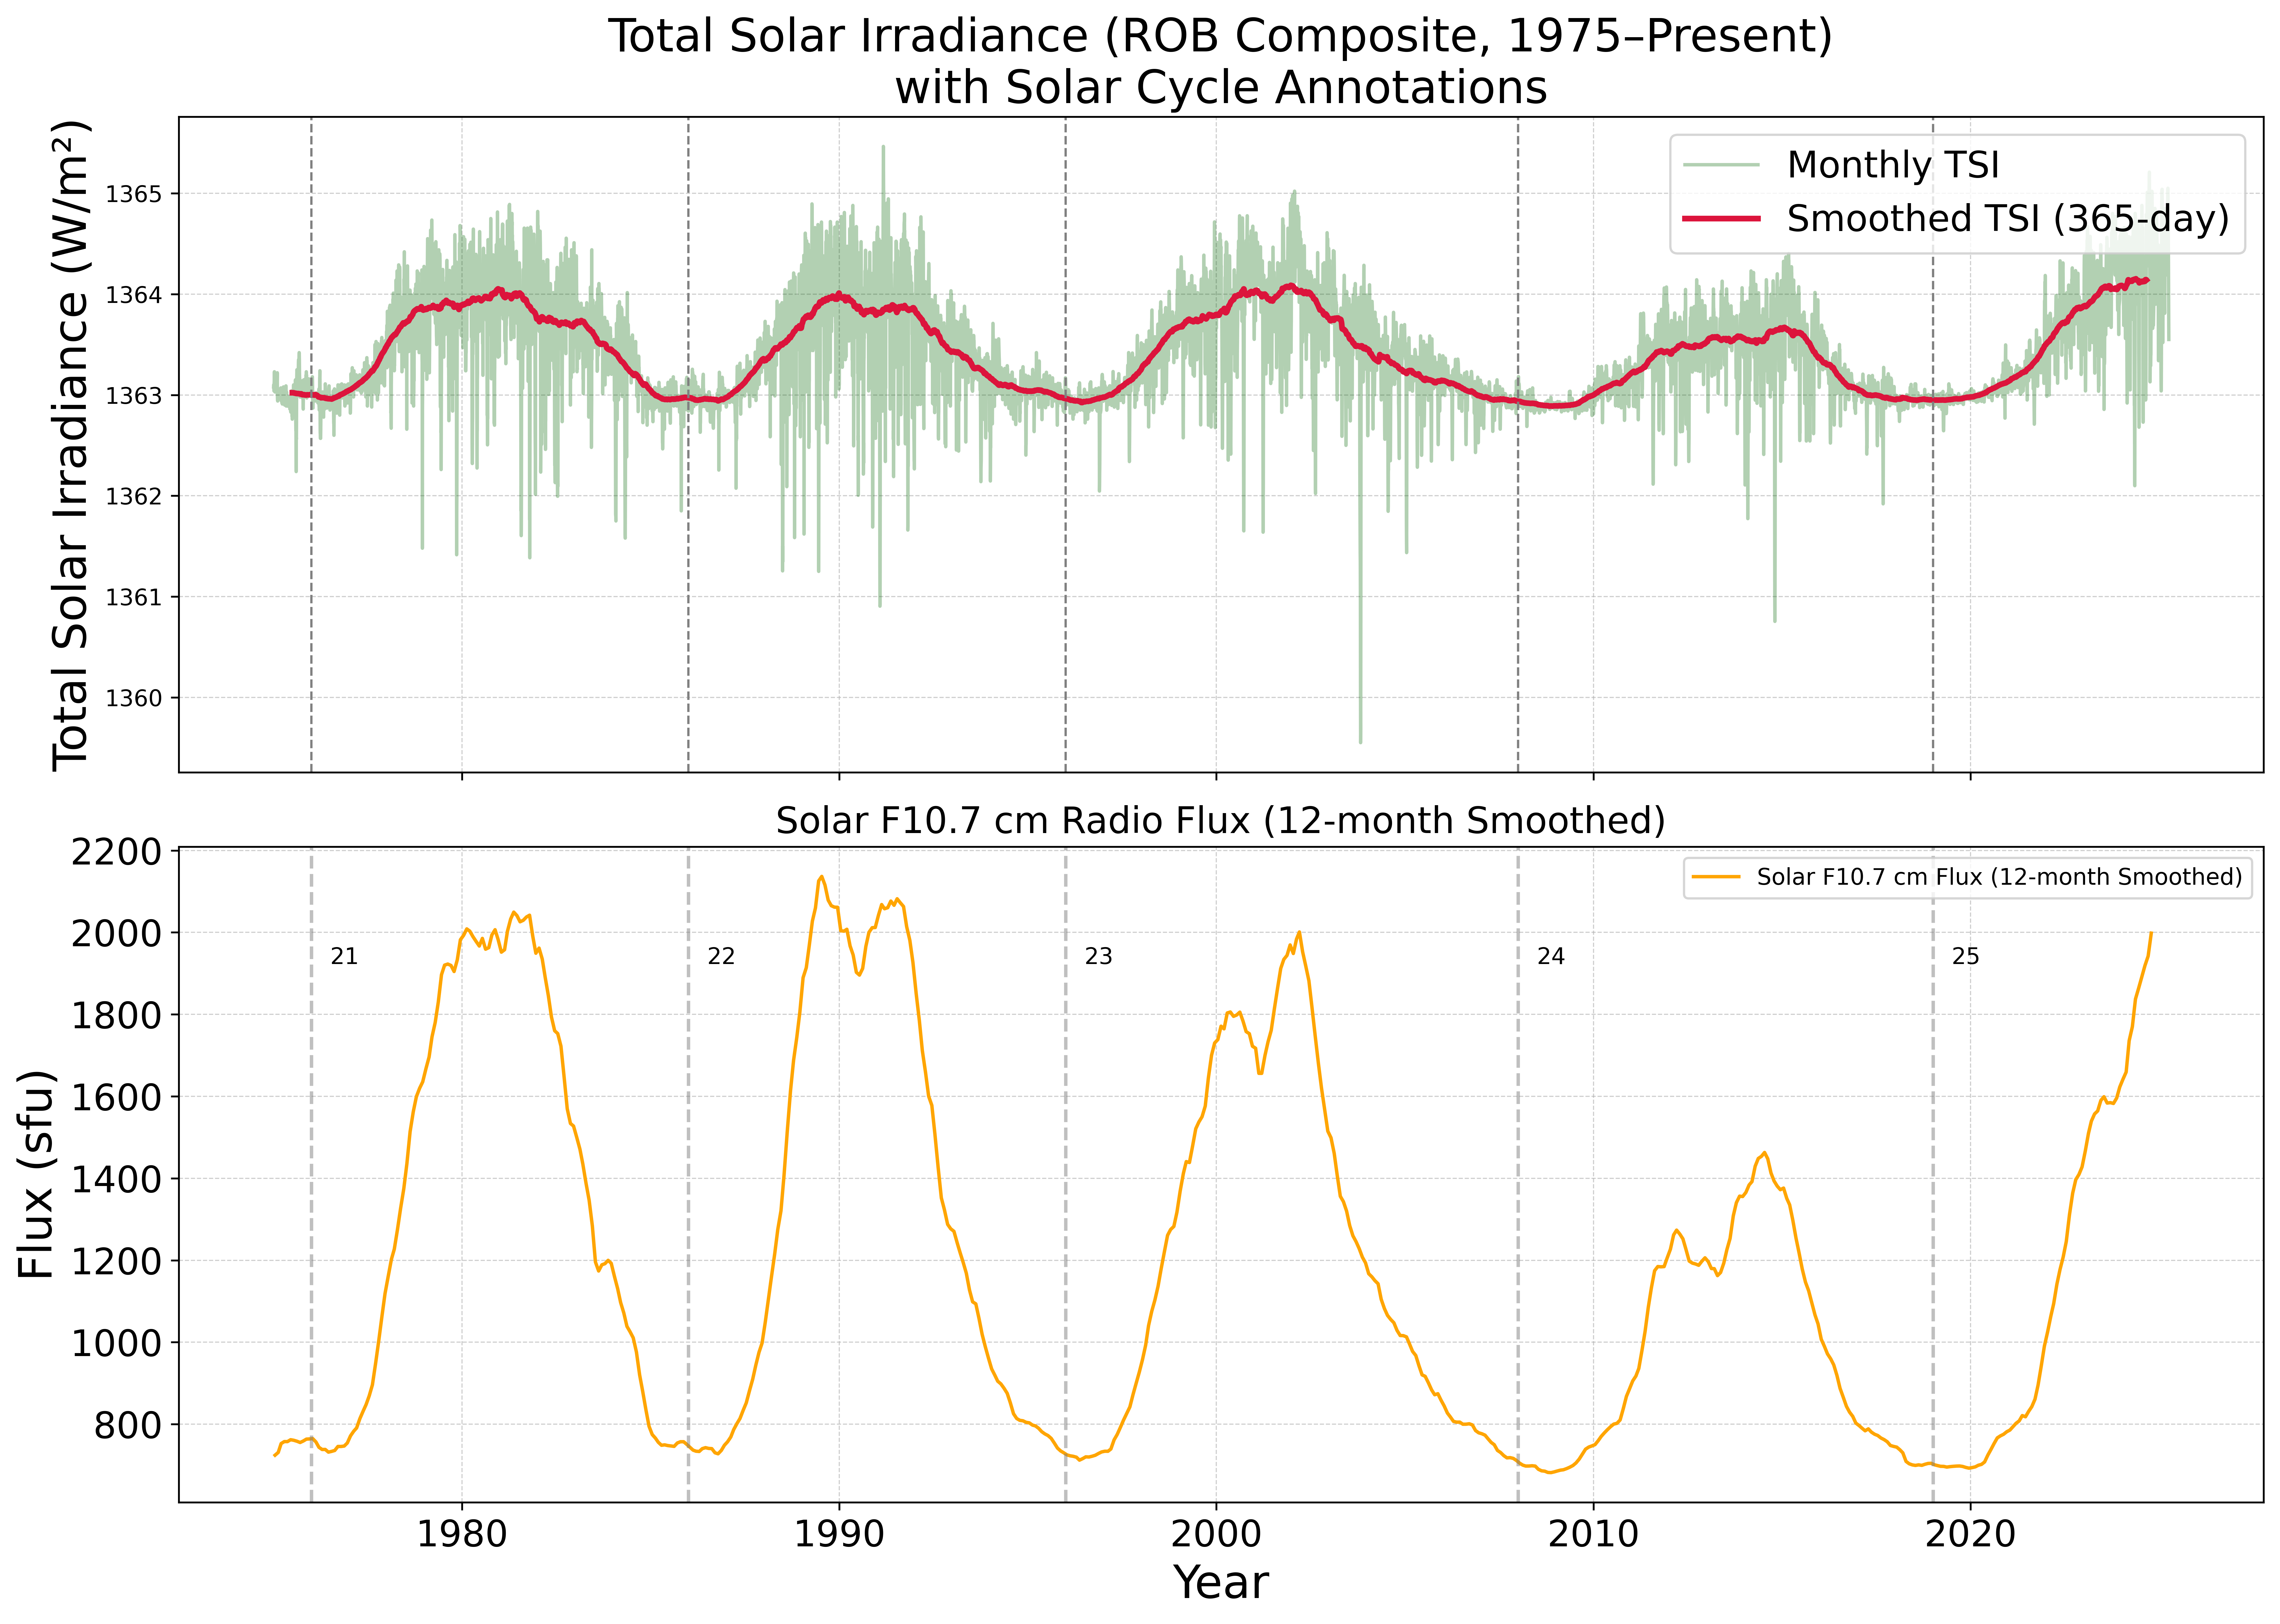

In [12]:
# === Plot Enhanced TSI with annotations on first row and F10.7 on second row ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)

# --- First Plot: TSI ---
ax1.plot(df_tsi_filtered["Date"], df_tsi_filtered["TSI"], color='darkgreen', alpha=0.3, label='Monthly TSI')
ax1.plot(df_tsi_filtered["Date"], df_tsi_filtered["Smoothed"], color='crimson', linewidth=2.5, label='Smoothed TSI (365-day)')
for year, number in zip(cycle_years, cycle_numbers):
    ax1.axvline(pd.Timestamp(f"{year}-01-01"), color='gray', linestyle='--', linewidth=1)
ax1.set_title("Total Solar Irradiance (ROB Composite, 1975–Present)\nwith Solar Cycle Annotations", fontsize=20)
ax1.set_ylabel("Total Solar Irradiance (W/m²)", fontsize=20)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend(loc='upper right', fontsize=16)

# --- Second Plot: Solar F10.7 ---
ax2.plot(df_filtered['date'], df_filtered['Smoothed'], label='Solar F10.7 cm Flux (12-month Smoothed)', color='orange')
for y, n in zip(cycle_years, cycle_numbers):
    ax2.axvline(pd.Timestamp(f"{y}-01-01"), color='gray', linestyle='--', alpha=0.5)
    ax2.text(pd.Timestamp(f"{y}-07-01"), df_filtered['Smoothed'].max()*0.9, str(n), rotation=0)
ax2.set_title('Solar F10.7 cm Radio Flux (12-month Smoothed)', fontsize=16)
ax2.set_xlabel('Year', fontsize=20)
ax2.set_ylabel('Flux (sfu)', fontsize=20)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax2.legend()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


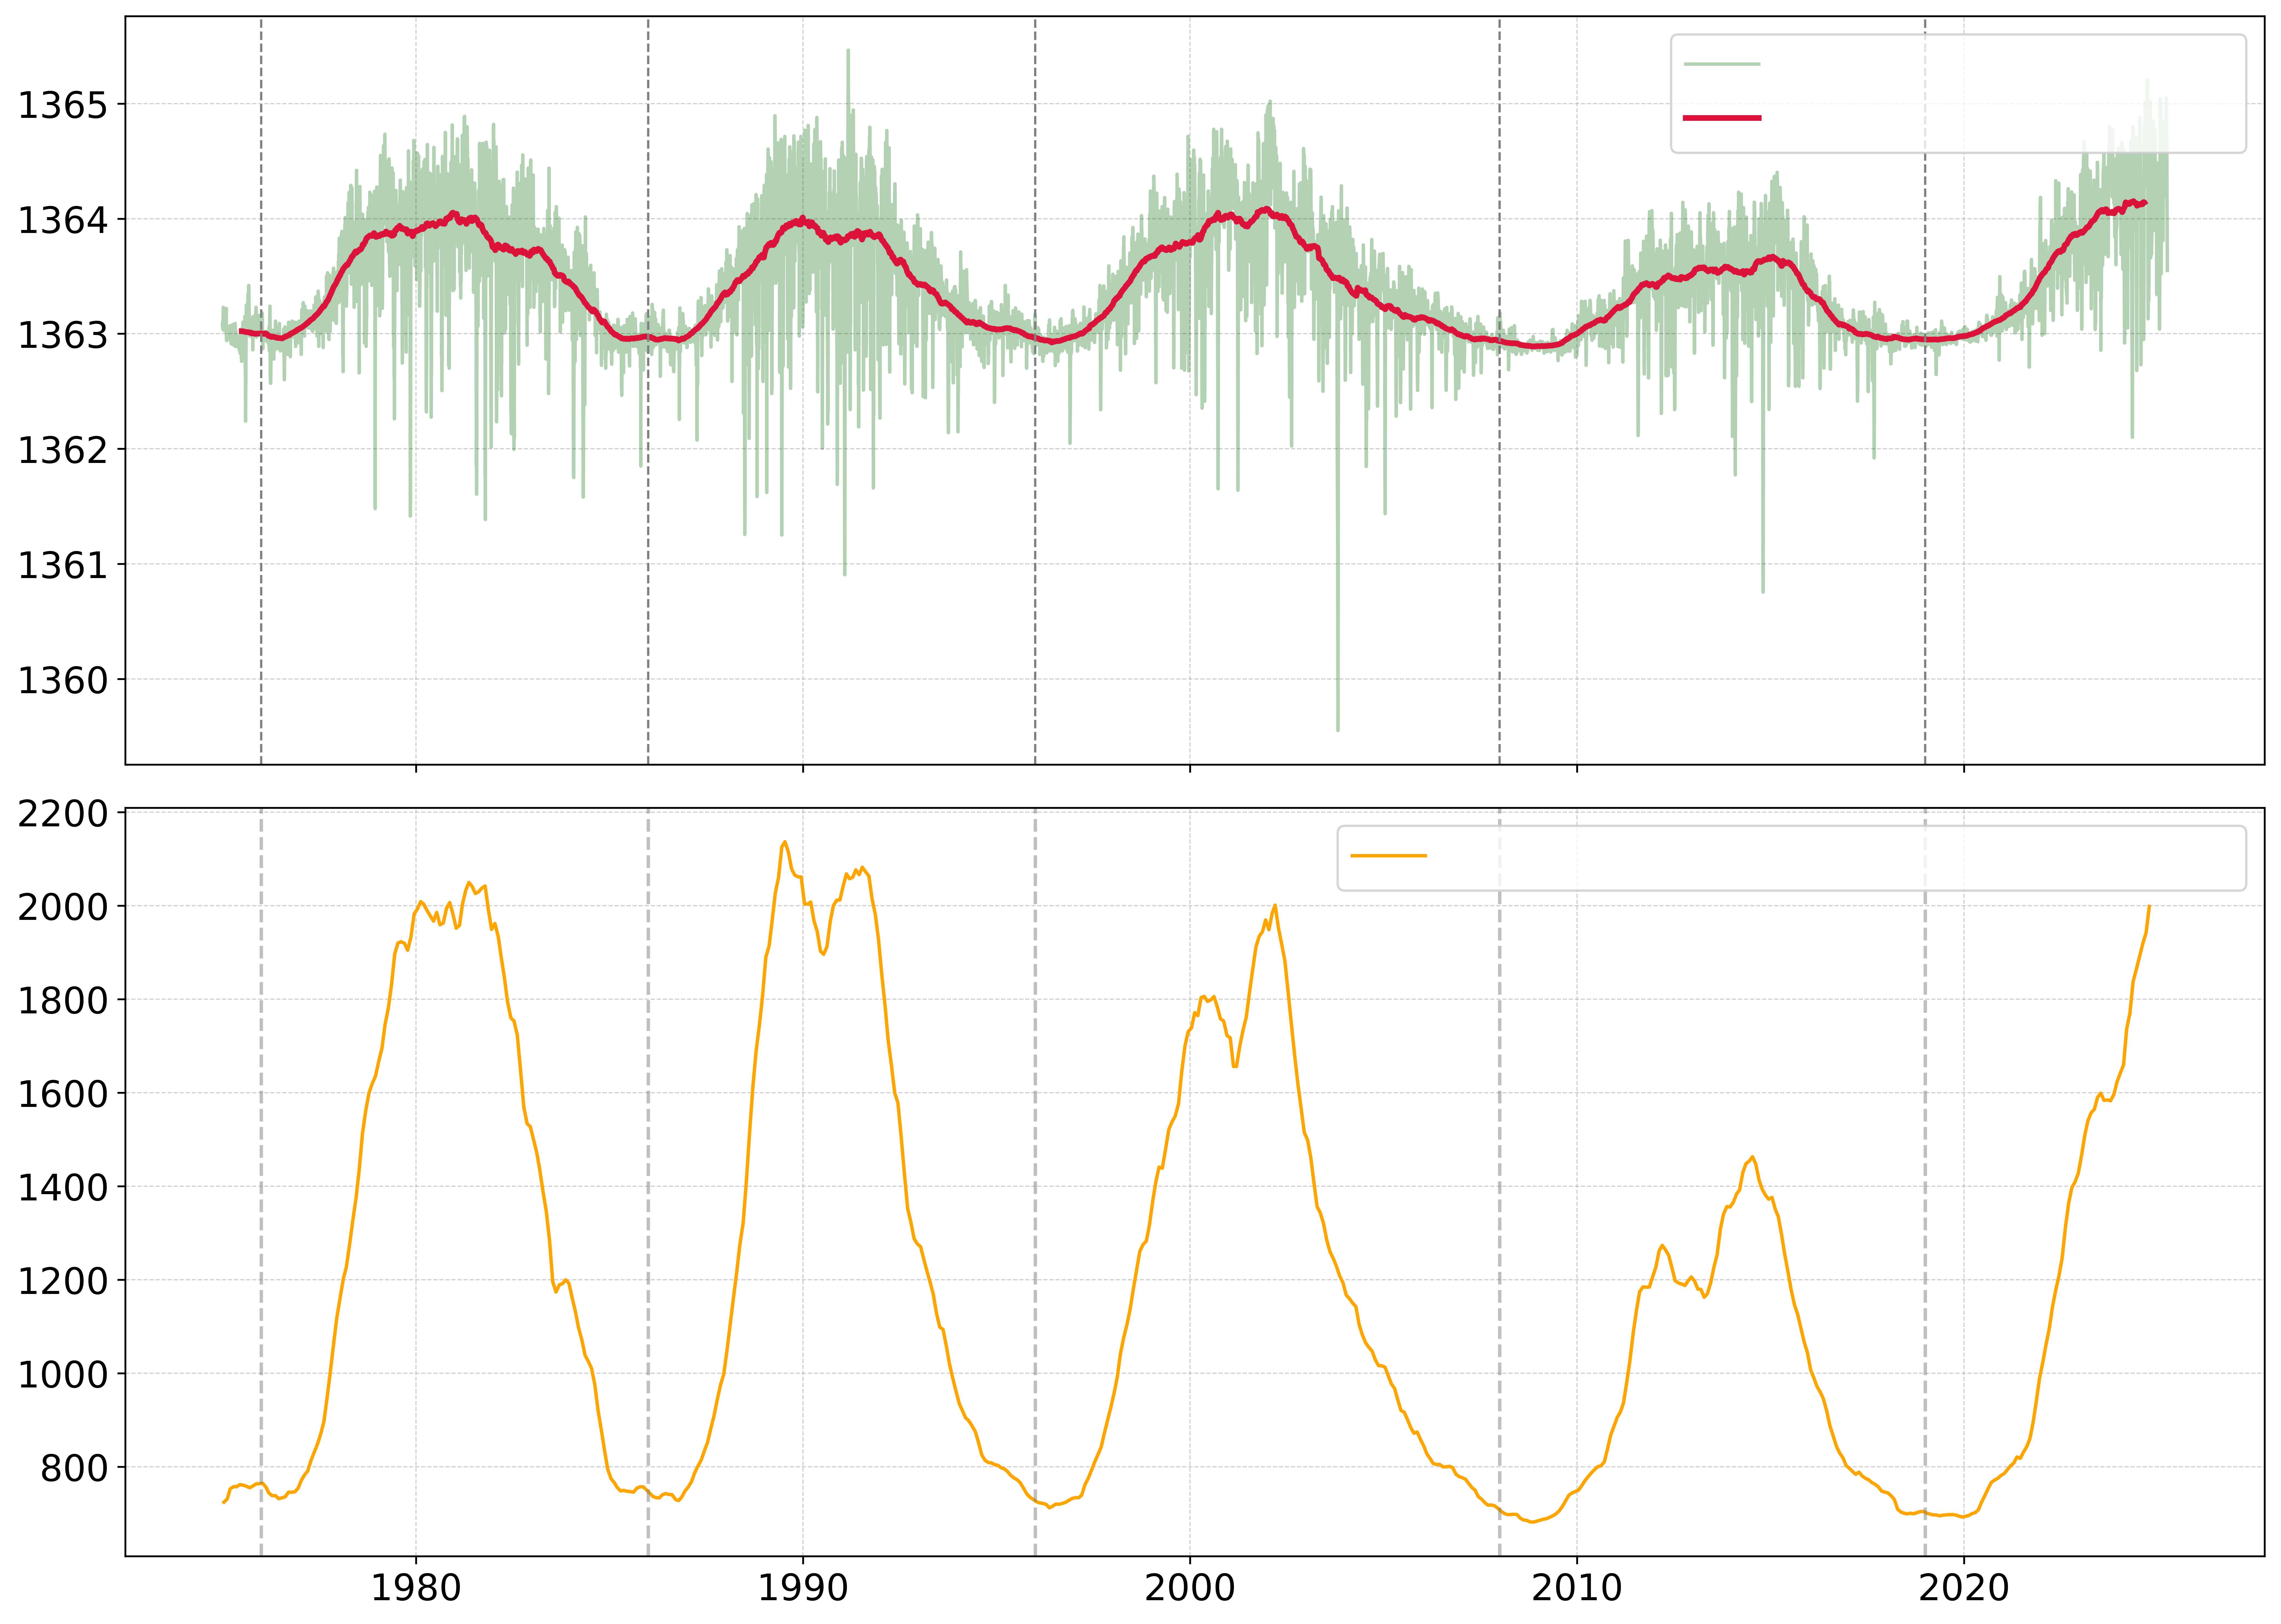

In [13]:
# === Plot Enhanced TSI with annotations on first row and F10.7 on second row ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=600, sharex=True)

# --- First Plot: TSI ---
ax1.plot(df_tsi_filtered["Date"], df_tsi_filtered["TSI"], color='darkgreen', alpha=0.3, label='Monthly TSI')
ax1.plot(df_tsi_filtered["Date"], df_tsi_filtered["Smoothed"], color='crimson', linewidth=2.5, label='Smoothed TSI (365-day)')
for year, number in zip(cycle_years, cycle_numbers):
    ax1.axvline(pd.Timestamp(f"{year}-01-01"), color='gray', linestyle='--', linewidth=1)
#ax1.set_title("Total Solar Irradiance (ROB Composite, 1975–Present)\nwith Solar Cycle Annotations", fontsize=20)
#ax1.set_ylabel("Total Solar Irradiance (W/m²)", fontsize=20)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
legend1 = ax1.legend(loc='upper right', fontsize=16)
for text in legend1.get_texts():
    text.set_alpha(0.0)
ax1.tick_params(axis='y', labelsize=16)
    
# --- Second Plot: Solar F10.7 ---
ax2.plot(df_filtered['date'], df_filtered['Smoothed'], label='Solar F10.7 cm Flux (12-month Smoothed)', color='orange')
for y, n in zip(cycle_years, cycle_numbers):
    ax2.axvline(pd.Timestamp(f"{y}-01-01"), color='gray', linestyle='--', alpha=0.5)
#    ax2.text(pd.Timestamp(f"{y}-07-01"), df_filtered['Smoothed'].max()*0.9, str(n), rotation=0)
#ax2.set_title('Solar F10.7 cm Radio Flux (12-month Smoothed)', fontsize=16)
#ax2.set_xlabel('Year', fontsize=20)
#ax2.set_ylabel('Flux (sfu)', fontsize=20)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
legend2 = ax2.legend(loc='upper right', fontsize=16)
for text in legend2.get_texts():
    text.set_alpha(0.0)
    
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()